In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib widget


In [2]:
df = pd.read_csv('../Datasets/scrap price.csv')

In [3]:
# Matriz de características X y vector objetivo y
X = df[["enginesize"]].values
y = df["price"].values.reshape(-1, 1)
y = y[: None]
print(X.shape)
print(y.shape)

(205, 1)
(205, 1)


In [4]:
## Z-score estandarización o normalización
m = np.mean(X, axis=0)
std = np.std(X, axis=0)
X = (X - m) / std

m_y = np.mean(y)
std_y = np.std(y)
y = (y - m_y) / std_y

In [5]:
# sesgo (bias)
X_b = np.c_[np.ones((len(X), 1)), X]

### Gradiente Descendente (GD)

In [6]:
m = len(y)

# def fun_costo(X, y, theta):
#     return (X.T @ (X @ theta - y)) / len(y)

# Gradiente Descendente 
def GD(X, y, lr=0.01, iters=1000):
    theta = np.zeros((2,1))
    trayectoria = []

    for i in range(iters):
        grad = (X.T @ (X @ theta - y)) / len(y)
        theta = theta - lr*grad
        trayectoria.append(theta.copy())

    return np.array(trayectoria)

### Gradiente Descendente Estocástico (SGD)

In [7]:
def SGD(X, y, lr=0.01, iters=1000):
    theta = np.zeros((2,1))
    trayectoria = []
    m = len(y)

    for i in range(iters):
        idx = np.random.randint(m)
        X_i = X[idx:idx+1]
        y_i = y[idx:idx+1]

        grad = X_i.T @ (X_i @ theta - y_i)
        theta = theta - lr*grad
        trayectoria.append(theta.copy())

    return np.array(trayectoria)

### Gradiente Descendente Estocástico con Momentum (SDGM)

In [8]:
def SDGM(X, y, lr=0.01, beta=0.9, iters=1000):
    theta = np.zeros((2,1))
    v = np.zeros_like(theta)
    trayectoria = []
    m = len(y)

    for i in range(iters):
        idx = np.random.randint(m)
        X_i = X[idx:idx+1]
        y_i = y[idx:idx+1]

        grad = X_i.T @ (X_i @ theta - y_i)

        v = beta*v + (1-beta)*grad
        theta = theta - lr*v

        trayectoria.append(theta.copy())

    return np.array(trayectoria)

### RMSProp

In [9]:
def RMSProp(X, y, lr=1e-3, beta=0.9, eps=1e-8, iters=1000):
    theta = np.zeros((2,1))
    s = np.zeros_like(theta)
    trayectoria = []
    m = len(y)

    for i in range(iters):
        idx = np.random.randint(m)
        X_i = X[idx:idx+1]
        y_i = y[idx:idx+1]

        grad = X_i.T @ (X_i @ theta - y_i)

        s = beta*s + (1-beta)*(grad**2)
        theta = theta - lr * grad / (np.sqrt(s) + eps)

        trayectoria.append(theta.copy())

    return np.array(trayectoria)

### ADAM

In [10]:
def Adam(X, y, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, iters=1000):
    theta = np.zeros((2,1))
    m_t = np.zeros_like(theta)
    v_t = np.zeros_like(theta)
    trayectoria = []

    for t in range(1, iters+1):

        idx = np.random.randint(len(y))
        X_i = X[idx:idx+1]
        y_i = y[idx:idx+1]

        grad = X_i.T @ (X_i @ theta - y_i)

        m_t = beta1*m_t + (1-beta1)*grad
        v_t = beta2*v_t + (1-beta2)*(grad**2)

        m_hat = m_t / (1 - beta1**t)
        v_hat = v_t / (1 - beta2**t)

        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)

        trayectoria.append(theta.copy())

    return np.array(trayectoria)

In [11]:
trayectoria_gd = GD(X_b, y)
trayectoria_sgd = SGD(X_b, y)
trayectoria_sdgm = SDGM(X_b, y)
trayectoria_rms = RMSProp(X_b, y)
trayectoria_adam = Adam(X_b, y)

all_traj = np.vstack([
    trayectoria_gd.reshape(-1,2),
    trayectoria_sgd.reshape(-1,2),
    trayectoria_sdgm.reshape(-1,2),
    trayectoria_rms.reshape(-1,2),
    trayectoria_adam.reshape(-1,2)
])

theta0_min, theta0_max = all_traj[:,0].min(), all_traj[:,0].max()
theta1_min, theta1_max = all_traj[:,1].min(), all_traj[:,1].max()

theta0_vals = np.linspace(theta0_min-1, theta0_max+1, 100)
theta1_vals = np.linspace(theta1_min-1, theta1_max+1, 100)

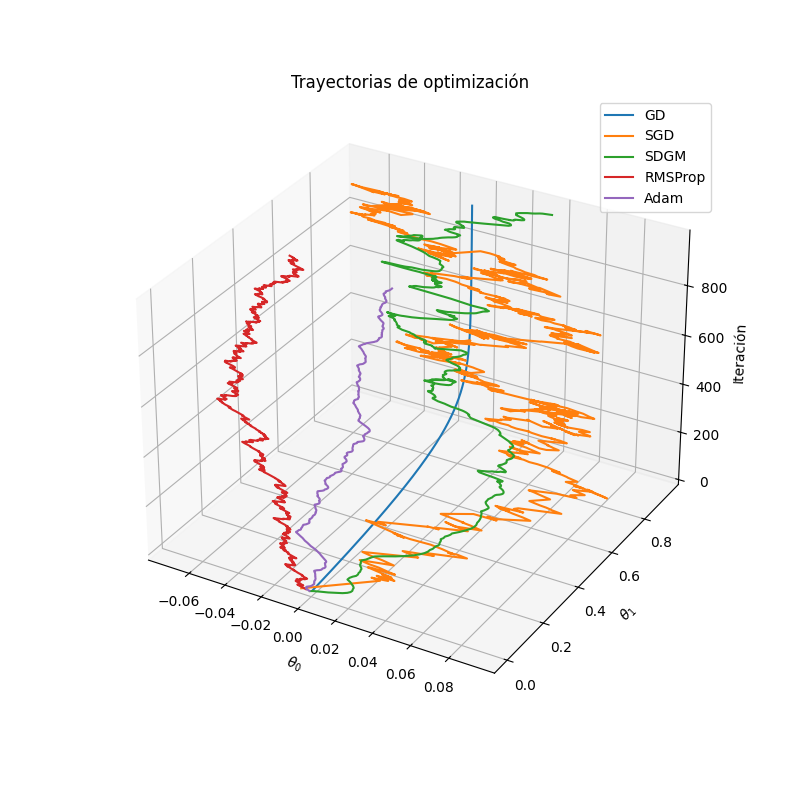

In [12]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

def plot_traj(traj, label):
    iters = np.arange(len(traj))
    ax.plot(traj[:,0,0], traj[:,1,0], iters, label=label)

plot_traj(trayectoria_gd, "GD")
plot_traj(trayectoria_sgd, "SGD")
plot_traj(trayectoria_sdgm, "SDGM")
plot_traj(trayectoria_rms, "RMSProp")
plot_traj(trayectoria_adam, "Adam")

ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel("Iteración")
ax.legend()

plt.title("Trayectorias de optimización")
plt.show()


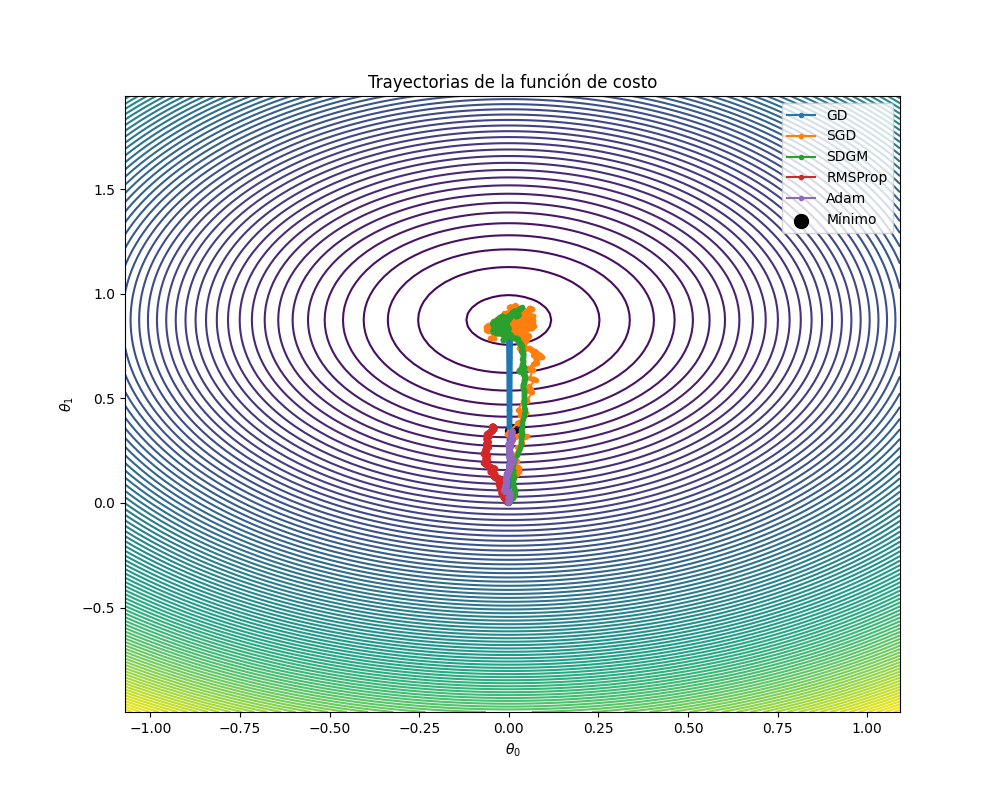

In [14]:
def compute_cost(X, y, theta):
    m = len(y)
    return np.sum((X @ theta - y)**2) / (2*m)

theta0_vals = np.linspace(theta0_min-1, theta0_max+1, 100)
theta1_vals = np.linspace(theta1_min-1, theta1_max+1, 100)

J_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        theta_temp = np.array([[theta0_vals[i]], [theta1_vals[j]]])
        J_vals[i,j] = compute_cost(X_b, y, theta_temp)

theta0_vals, theta1_vals = np.meshgrid(theta0_vals, theta1_vals)

def plot_traj_2d(traj, label):
    plt.plot(traj[:,0,0], traj[:,1,0], marker='o', markersize=3, label=label)

plt.figure(figsize=(10,8))
plt.contour(theta0_vals, theta1_vals, J_vals.T, levels=100)

plot_traj_2d(trayectoria_gd, "GD")
plot_traj_2d(trayectoria_sgd, "SGD")
plot_traj_2d(trayectoria_sdgm, "SDGM")
plot_traj_2d(trayectoria_rms, "RMSProp")
plot_traj_2d(trayectoria_adam, "Adam")

theta_min = trayectoria_adam[-1]

plt.scatter(theta_min[0,0], theta_min[1,0],
            c='black', s=100, label='Mínimo')

plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.title("Trayectorias de la función de costo")
plt.legend()

plt.show()